INFO     | ======================================================================
INFO     | Starting analysis: figure_s1
INFO     | Log file: outputs/logs/figure_s1_20260227_223837.log
INFO     | Timestamp: 2026-02-27 22:38:37
INFO     | ======================================================================
INFO     | Loading configuration...
INFO     | Functions defined
INFO     | Loading OSISAF data from: ../../osi-sea_ice_index/
INFO     | Season: March (month 3)
INFO     | Processing: Creating 4-panel supplementary figure
INFO     | Creating Panel (a): Pan-Arctic PWLR
INFO     | Detected breakpoint: 2017.00 (rounded to 2017)
INFO     | Segment 1 (before 2017) R²: 0.745, p: 0.0000
INFO     | Segment 2 (from 2017) R²: 0.013, p: 0.7705
INFO     | Created processed_data: pwlr_pan_arctic.csv
INFO     | Creating Panel (b): Greenland Sea PWLR
INFO     | Detected breakpoint: 2015.80 (rounded to 2016)
INFO     | Segment 1 (before 2016) R²: 0.488, p: 0.0000
INFO     | Segment 2 (from 2016) 

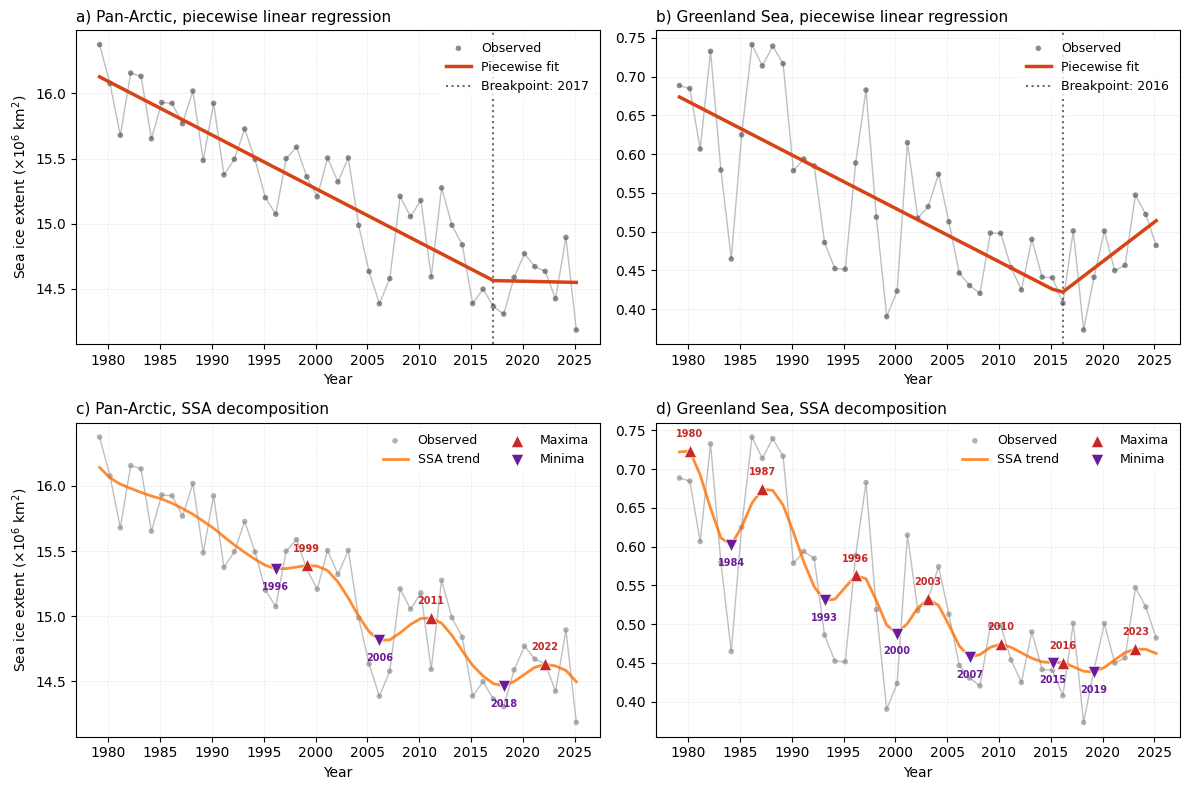

INFO     | Methods documentation saved: outputs/methods/figure_s1_methods.md
INFO     | Created methods: figure_s1_methods.md
INFO     | ======================================================================
INFO     | Analysis completed successfully
INFO     | Total elapsed time: 0:00:16
INFO     | ======================================================================
INFO     | ======================================================================
INFO     | FIGURE S1 COMPLETE
INFO     | ======================================================================


In [17]:
"""
Figure S1: Piecewise Linear Regression and SSA Trend Decomposition
===================================================================

Four-panel supplementary figure:
- Panel (a): Pan-Arctic piecewise linear regression
- Panel (b): Greenland Sea piecewise linear regression
- Panel (c): Pan-Arctic SSA decomposition with extrema
- Panel (d): Greenland Sea SSA decomposition with extrema

Version: 1.0.0
Last Modified: 2026-02-27
"""

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as dates
from scipy import stats
import pwlf
from pyts.decomposition import SingularSpectrumAnalysis
from scipy.signal import find_peaks
import os
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Setup logging
import sys
sys.path.append('..')
from utils.logger import (setup_logger, log_data_loading, log_processing_step,
                          log_output_file, log_completion, log_error)

logger = setup_logger('figure_s1', config_path='../config.yaml')
start_time = datetime.now()

try:
    # ========================================================================
    # CONFIGURATION
    # ========================================================================
    
    logger.info("Loading configuration...")
    
    # File paths
    OSISAF_PATH = '../../osi-sea_ice_index/'
    
    # Create output directories
    OUTPUT_DIR = Path('./outputs/figures')
    PROCESSED_DIR = Path('./outputs/processed_data/figure_s1')
    METHODS_DIR = Path('./outputs/methods')
    
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    METHODS_DIR.mkdir(parents=True, exist_ok=True)
    
    # Configuration
    CONFIG = {
        'season': 'winter',
        'n_bootstrap': 1000,
        'confidence_level': 0.95
    }
    
    # Colors
    COLORS = {
        'data': '#424242',
        'pwlr_fit': '#D84315',
        'breakpoint': '#263238',
        'ssa_trend': '#FF6F00',
        'peaks': '#C62828',
        'troughs': '#6A1B9A'
    }
    
    DPI = 600
    
    # ========================================================================
    # FUNCTIONS
    # ========================================================================
    
    def mann_kendall_test(x, y):
        """Mann-Kendall trend test for monotonic trends."""
        y = np.asarray(y)
        n = len(y)
        s = 0
        
        for i in range(n-1):
            for j in range(i+1, n):
                s += np.sign(y[j] - y[i])
        
        var_s = n * (n - 1) * (2 * n + 5) / 18
        
        if s > 0:
            z = (s - 1) / np.sqrt(var_s)
        elif s < 0:
            z = (s + 1) / np.sqrt(var_s)
        else:
            z = 0
        
        p_value = 2 * (1 - stats.norm.cdf(abs(z)))
        tau = s / (0.5 * n * (n - 1))
        
        if p_value < 0.05:
            trend = 'increasing' if tau > 0 else 'decreasing'
        else:
            trend = 'no trend'
        
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'n.s.'
        
        return {'tau': tau, 'p_value': p_value, 'trend': trend, 'significance': significance}
    
    
    def analytical_trend_ci(x, y, confidence=0.95):
        """Analytical confidence intervals for linear regression."""
        x = np.asarray(x)
        y = np.asarray(y)
        n = len(y)
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        y_fit = slope * x + intercept
        
        residuals = y - y_fit
        mse = np.sum(residuals**2) / (n - 2)
        
        x_mean = np.mean(x)
        se_line = np.sqrt(mse * (1/n + (x - x_mean)**2 / np.sum((x - x_mean)**2)))
        
        t_val = stats.t.ppf((1 + confidence) / 2, n - 2)
        
        margin = t_val * se_line
        lower_bound = y_fit - margin
        upper_bound = y_fit + margin
        
        se_slope = std_err
        trend_ci = (slope - t_val * se_slope, slope + t_val * se_slope)
        
        return {
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'trend_ci': trend_ci,
            'r_squared': r_value**2,
            'p_value': p_value,
            'slope': slope,
            'std_err': std_err
        }
    
    
    def perform_ssa_analysis(data, times, window_fraction=0.15):
        """Perform SSA trend decomposition."""
        data = np.asarray(data)
        n = len(data)
        window_size = max(10, int(window_fraction * n))
        
        ssa = SingularSpectrumAnalysis(window_size=window_size, groups=None)
        X_ssa = ssa.fit_transform(data.reshape(1, -1))
        
        trend = X_ssa[0, 0] + X_ssa[0, 1]
        
        peaks, _ = find_peaks(trend, distance=int(0.05 * n))
        troughs, _ = find_peaks(-trend, distance=int(0.05 * n))
        
        return {'trend': trend, 'peaks': peaks, 'troughs': troughs}
    
    
    def add_months(ds):
        """Add month coordinate to xarray dataset."""
        ds.coords['month'] = xr.DataArray(np.zeros(ds.time.shape), coords={'time': ds.time})
        for i, t in enumerate(ds.time):
            t = t.data
            month = t.astype('M8[M]').astype(int) % 12 + 1
            ds.coords['month'][i] = month
        return ds
    
    
    def fetch_sie(region, sie_list):
        """Fetch sea ice extent data for specified region."""
        for sie in sie_list:
            if sie.name == region:
                return sie
        raise ValueError(f"Region '{region}' not found in sie_list")
    
    logger.info("Functions defined")
    
    # ========================================================================
    # LOAD DATA
    # ========================================================================
    
    log_data_loading(logger, 'OSISAF', OSISAF_PATH)
    f_list = os.listdir(OSISAF_PATH)
    
    sie_list = []
    for f in f_list:
        ds = xr.open_dataset(OSISAF_PATH + f)
        ds_monthly = ds.drop_vars('area').resample(time='MS').mean()
        ds_monthly = add_months(ds_monthly)
        
        f_info = f.split('_')
        region = f_info[1]
        title_info = ds.title.split()
        for i, word in enumerate(title_info):
            if word == 'Ice':
                region_name = ' '.join(title_info[1:i-1])
        
        sie = ds_monthly.sie
        sie = sie.rename(region)
        sie.attrs['title'] = ds.title
        sie.attrs['region_name'] = region_name
        sie.attrs['summary'] = ds.summary
        sie_list.append(sie)
    
    ds_nh = fetch_sie('nh', sie_list)
    ds_gs = fetch_sie('fram', sie_list)
    
    # Select season
    if CONFIG['season'] == 'winter':
        season_month = 3
        season_name = 'March'
    else:
        season_month = 9
        season_name = 'September'
    
    logger.info(f"Season: {season_name} (month {season_month})")
    
    # ========================================================================
    # CREATE FIGURE
    # ========================================================================
    
    log_processing_step(logger, "Creating 4-panel supplementary figure")
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    # ====================================================================
    # PANEL A: PAN-ARCTIC PIECEWISE LINEAR REGRESSION
    # ====================================================================
    
    logger.info("Creating Panel (a): Pan-Arctic PWLR")
    ax = axes[0]
    
    x_data = ds_nh.time.where(ds_nh.month == season_month, drop=True)
    y_data = ds_nh.where(ds_nh.month == season_month, drop=True)
    
    # Convert to numeric
    x_num = x_data.dt.year.values
    y_num = y_data.values
    
    # Fit piecewise linear model
    my_pwlf = pwlf.PiecewiseLinFit(x_num, y_num)
    breaks = my_pwlf.fit(2)
    y_hat = my_pwlf.predict(x_num)
    
    # Round breakpoint to nearest year for display
    breakpoint_year = int(np.round(breaks[1]))
    
    # Set breakpoint date to March of the rounded year to align with data
    np_break_date = pd.Timestamp(year=breakpoint_year, month=season_month, day=1)
    
    logger.info(f"Detected breakpoint: {breaks[1]:.2f} (rounded to {breakpoint_year})")
    
    # Calculate statistics for each segment
    seg1_mask = x_num < breakpoint_year
    seg2_mask = x_num >= breakpoint_year
    seg1_stats = analytical_trend_ci(x_num[seg1_mask], y_data.values[seg1_mask])
    seg2_stats = analytical_trend_ci(x_num[seg2_mask], y_data.values[seg2_mask])
    
    logger.info(f"Segment 1 (before {breakpoint_year}) R²: {seg1_stats['r_squared']:.3f}, p: {seg1_stats['p_value']:.4f}")
    logger.info(f"Segment 2 (from {breakpoint_year}) R²: {seg2_stats['r_squared']:.3f}, p: {seg2_stats['p_value']:.4f}")
    
    # Plot
    ax.plot(x_data, y_data, color='#808080', linewidth=1, alpha=0.5, zorder=1)
    ax.scatter(x_data, y_data, s=16, color=COLORS['data'], alpha=0.6,
              label='Observed', zorder=2, edgecolors='none')
    
    # Plot fitted line using March dates to align with data
    x_plot = pd.DatetimeIndex([pd.Timestamp(year=int(yr), month=season_month, day=1) for yr in x_num])
    ax.plot(x_plot, y_hat, color=COLORS['pwlr_fit'], linewidth=2.5,
           label='Piecewise fit', zorder=3)
    
    # Vertical line at March of rounded breakpoint year
    ax.axvline(x=np_break_date, color=COLORS['breakpoint'], linestyle=':',
              linewidth=1.5, alpha=0.7,
              label=f"Breakpoint: {breakpoint_year}", zorder=1)
    
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(r'Sea ice extent ($\times10^{6}$ km$^{2}$)', fontsize=10)
    ax.set_title(f'a) Pan-Arctic, piecewise linear regression', loc='left',
                fontsize=11)
    ax.legend(loc='upper right', frameon=True, edgecolor='none', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Save processed data
    pwlr_nh_data = pd.DataFrame({
        'time': x_data.values,
        'observed': y_data.values,
        'fitted': y_hat,
        'breakpoint_year': breakpoint_year,
        'breakpoint_detected': breaks[1]  # Save the precise detected value
    })
    pwlr_nh_file = PROCESSED_DIR / 'pwlr_pan_arctic.csv'
    pwlr_nh_data.to_csv(pwlr_nh_file, index=False)
    log_output_file(logger, 'processed_data', pwlr_nh_file)
    
    # ====================================================================
    # PANEL B: GREENLAND SEA PIECEWISE LINEAR REGRESSION
    # ====================================================================
    
    logger.info("Creating Panel (b): Greenland Sea PWLR")
    ax = axes[1]
    
    x_data = ds_gs.time.where(ds_gs.month == season_month, drop=True)
    y_data = ds_gs.where(ds_gs.month == season_month, drop=True)
    
    # Convert to numeric
    x_num = x_data.dt.year.values
    y_num = y_data.values
    
    # Fit piecewise linear model
    my_pwlf = pwlf.PiecewiseLinFit(x_num, y_num)
    breaks = my_pwlf.fit(2)
    y_hat = my_pwlf.predict(x_num)
    
    # Round breakpoint to nearest year for display
    # Since breaks[1] ≈ 2015.8 (August 2015), this rounds to 2016
    breakpoint_year = int(np.round(breaks[1]))
    
    # Set breakpoint date to March of the rounded year to align with data
    np_break_date = pd.Timestamp(year=breakpoint_year, month=season_month, day=1)
    
    logger.info(f"Detected breakpoint: {breaks[1]:.2f} (rounded to {breakpoint_year})")
    
    # Calculate statistics for each segment
    seg1_mask = x_num < breakpoint_year
    seg2_mask = x_num >= breakpoint_year
    seg1_stats = analytical_trend_ci(x_num[seg1_mask], y_data.values[seg1_mask])
    seg2_stats = analytical_trend_ci(x_num[seg2_mask], y_data.values[seg2_mask])
    
    logger.info(f"Segment 1 (before {breakpoint_year}) R²: {seg1_stats['r_squared']:.3f}, p: {seg1_stats['p_value']:.4f}")
    logger.info(f"Segment 2 (from {breakpoint_year}) R²: {seg2_stats['r_squared']:.3f}, p: {seg2_stats['p_value']:.4f}")
    
    # Plot
    ax.plot(x_data, y_data, color='#808080', linewidth=1, alpha=0.5, zorder=1)
    ax.scatter(x_data, y_data, s=16, color=COLORS['data'], alpha=0.6,
              label='Observed', zorder=2, edgecolors='none')
    
    # Plot fitted line using March dates to align with data
    x_plot = pd.DatetimeIndex([pd.Timestamp(year=int(yr), month=season_month, day=1) for yr in x_num])
    ax.plot(x_plot, y_hat, color=COLORS['pwlr_fit'], linewidth=2.5,
           label='Piecewise fit', zorder=3)
    
    # Vertical line at March of rounded breakpoint year
    ax.axvline(x=np_break_date, color=COLORS['breakpoint'], linestyle=':',
              linewidth=1.5, alpha=0.7,
              label=f"Breakpoint: {breakpoint_year}", zorder=1)
    
    ax.set_xlabel('Year', fontsize=10)
    ax.set_title(f'b) Greenland Sea, piecewise linear regression', loc='left',
                fontsize=11)
    ax.legend(loc='upper right', frameon=True, edgecolor='none', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Save processed data
    pwlr_gs_data = pd.DataFrame({
        'time': x_data.values,
        'observed': y_data.values,
        'fitted': y_hat,
            'breakpoint_year': breakpoint_year,
            'breakpoint_detected': breaks[1]  # Save the precise detected value
        })
    pwlr_gs_file = PROCESSED_DIR / 'pwlr_greenland_sea.csv'
    pwlr_gs_data.to_csv(pwlr_gs_file, index=False)
    log_output_file(logger, 'processed_data', pwlr_gs_file)
    
    # ====================================================================
    # PANEL C: PAN-ARCTIC SSA DECOMPOSITION
    # ====================================================================
    
    logger.info("Creating Panel (c): Pan-Arctic SSA")
    ax = axes[2]
    
    x_data = ds_nh.time.where(ds_nh.month == season_month, drop=True)
    y_data = ds_nh.where(ds_nh.month == season_month, drop=True)
    
    ssa_results = perform_ssa_analysis(y_data.values, x_data)
    
    # Plot observed data
    ax.plot(x_data, y_data, color='#808080', linewidth=1, alpha=0.5, zorder=1)
    ax.scatter(x_data, y_data, s=16, color='#808080', alpha=0.6,
              label='Observed', zorder=2, edgecolors='none')
    
    # Plot SSA trend
    ax.plot(x_data, ssa_results['trend'], color=COLORS['ssa_trend'],
           linewidth=2, label='SSA trend', alpha=0.8, zorder=3)
    
    # Mark peaks and troughs
    peaks = ssa_results['peaks']
    troughs = ssa_results['troughs']
    
    ax.scatter(x_data[peaks], ssa_results['trend'][peaks],
             marker='^', s=80, color=COLORS['peaks'],
             label='Maxima', zorder=5, edgecolor='white', linewidth=0.5)
    ax.scatter(x_data[troughs], ssa_results['trend'][troughs],
             marker='v', s=80, color=COLORS['troughs'],
             label='Minima', zorder=5, edgecolor='white', linewidth=0.5)
    
    # Annotate peaks
    for i in peaks:
        ax.annotate(f"{str(x_data[i].data)[0:4]}",
                   (x_data[i], ssa_results['trend'][i]),
                   textcoords="offset points", xytext=(0, 10),
                   ha='center', fontsize=7, color=COLORS['peaks'],
                   fontweight='bold')
    
    # Annotate troughs
    for i in troughs:
        ax.annotate(f"{str(x_data[i].data)[0:4]}",
                   (x_data[i], ssa_results['trend'][i]),
                   textcoords="offset points", xytext=(0, -15),
                   ha='center', fontsize=7, color=COLORS['troughs'],
                   fontweight='bold')
    
    logger.info(f"Number of peaks detected: {len(peaks)}")
    logger.info(f"Number of troughs detected: {len(troughs)}")
    
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(r'Sea ice extent ($\times10^{6}$ km$^{2}$)', fontsize=10)
    ax.set_title(f'c) Pan-Arctic, SSA decomposition', loc='left',
                fontsize=11)
    ax.legend(loc='upper right', frameon=True, edgecolor='none', ncol=2, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Save processed data
    ssa_nh_data = pd.DataFrame({
        'time': x_data.values,
        'observed': y_data.values,
        'ssa_trend': ssa_results['trend']
    })
    ssa_nh_file = PROCESSED_DIR / 'ssa_pan_arctic.csv'
    ssa_nh_data.to_csv(ssa_nh_file, index=False)
    log_output_file(logger, 'processed_data', ssa_nh_file)
    
    # ====================================================================
    # PANEL D: GREENLAND SEA SSA DECOMPOSITION
    # ====================================================================
    
    logger.info("Creating Panel (d): Greenland Sea SSA")
    ax = axes[3]
    
    x_data = ds_gs.time.where(ds_gs.month == season_month, drop=True)
    y_data = ds_gs.where(ds_gs.month == season_month, drop=True)
    
    ssa_results = perform_ssa_analysis(y_data.values, x_data)
    
    # Plot observed data
    ax.plot(x_data, y_data, color='#808080', linewidth=1, alpha=0.5, zorder=1)
    ax.scatter(x_data, y_data, s=16, color='#808080', alpha=0.6,
              label='Observed', zorder=2, edgecolors='none')
    
    # Plot SSA trend
    ax.plot(x_data, ssa_results['trend'], color=COLORS['ssa_trend'],
           linewidth=2, label='SSA trend', alpha=0.8, zorder=3)
    
    # Mark peaks and troughs
    peaks = ssa_results['peaks']
    troughs = ssa_results['troughs']
    
    ax.scatter(x_data[peaks], ssa_results['trend'][peaks],
             marker='^', s=80, color=COLORS['peaks'],
             label='Maxima', zorder=5, edgecolor='white', linewidth=0.5)
    ax.scatter(x_data[troughs], ssa_results['trend'][troughs],
             marker='v', s=80, color=COLORS['troughs'],
             label='Minima', zorder=5, edgecolor='white', linewidth=0.5)
    
    # Annotate peaks
    for i in peaks:
        ax.annotate(f"{str(x_data[i].data)[0:4]}",
                   (x_data[i], ssa_results['trend'][i]),
                   textcoords="offset points", xytext=(0, 10),
                   ha='center', fontsize=7, color=COLORS['peaks'],
                   fontweight='bold')
    
    # Annotate troughs
    for i in troughs:
        ax.annotate(f"{str(x_data[i].data)[0:4]}",
                   (x_data[i], ssa_results['trend'][i]),
                   textcoords="offset points", xytext=(0, -15),
                   ha='center', fontsize=7, color=COLORS['troughs'],
                   fontweight='bold')
    
    logger.info(f"Number of peaks detected: {len(peaks)}")
    logger.info(f"Number of troughs detected: {len(troughs)}")
    
    ax.set_xlabel('Year', fontsize=10)
    ax.set_title(f'd) Greenland Sea, SSA decomposition', loc='left',
                fontsize=11)
    ax.legend(loc='upper right', frameon=True, edgecolor='none', ncol=2, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Save processed data
    ssa_gs_data = pd.DataFrame({
        'time': x_data.values,
        'observed': y_data.values,
        'ssa_trend': ssa_results['trend']
    })
    ssa_gs_file = PROCESSED_DIR / 'ssa_greenland_sea.csv'
    ssa_gs_data.to_csv(ssa_gs_file, index=False)
    log_output_file(logger, 'processed_data', ssa_gs_file)
    
    # ========================================================================
    # SAVE FIGURE
    # ========================================================================
    
    plt.tight_layout()
    
    output_file = OUTPUT_DIR / 'figure_s1.png'
    fig.savefig(output_file, dpi=DPI, bbox_inches='tight', facecolor='white')
    logger.info(f"Figure saved: {output_file}")
    log_output_file(logger, 'figure', output_file)
    
    plt.show()
    
    # ========================================================================
    # GENERATE METHODS DOCUMENTATION
    # ========================================================================
    
    methods_file = METHODS_DIR / 'figure_s1_methods.md'
    with open(methods_file, 'w') as f:
        f.write("""# Figure S1: Methodology

## Piecewise Linear Regression

### Method
Piecewise linear regression (PWLR) identifies structural breaks in timeseries data by fitting multiple linear segments with automated breakpoint detection (Muggeo, 2003; Toms & Lesperance, 2003).

The method minimizes the sum of squared residuals while determining optimal breakpoint locations:

minimize: Σᵢ (yᵢ - ŷᵢ)²

where ŷᵢ is the predicted value from the appropriate linear segment.

### Implementation
- **Software**: `pwlf` Python package (Jekel et al., 2019)
- **Number of segments**: 2 (one breakpoint)
- **Optimization**: Davies' algorithm for breakpoint estimation

For each segment, standard linear regression statistics were calculated:
- Coefficient of determination (R²)
- Slope significance (p-value from t-test)

### Interpretation
The identified breakpoints represent statistically significant changes in trend direction or magnitude. For March sea ice extent:
- **Pan-Arctic**: Breakpoint ≈ 2017
- **Greenland Sea**: Breakpoint ≈ 2015

These breakpoints justify the use of split linear trends in Figure 1.

## Singular Spectrum Analysis (SSA)

### Method
SSA is a non-parametric time series decomposition technique that separates trends, oscillations, and noise without assuming functional forms (Golyandina et al., 2001; Hassani, 2007).

The method embeds the time series in a trajectory matrix using lagged vectors:

X = [x₁, x₂, ..., xₙ]  
Window size L determines the dimension of embedding

Singular Value Decomposition (SVD) decomposes the trajectory matrix:
X = Σᵢ λᵢ Uᵢ Vᵢᵀ

where λᵢ are singular values, and Uᵢ, Vᵢ are left and right singular vectors.

### Implementation
- **Software**: `pyts` Python package (Faouzi & Janati, 2020)
- **Window size**: 15% of time series length (≈ 7 years for March data)
- **Trend extraction**: Sum of first two principal components (capturing low-frequency variability)
- **Extrema detection**: Local maxima/minima identified using `scipy.signal.find_peaks`

### Parameters
- **Minimum peak distance**: 5% of time series length (prevents detection of spurious extrema)
- **Prominence threshold**: Not applied (all local extrema included)

### Interpretation
SSA-derived trends reveal:
- **Pan-Arctic**: Multi-decadal decline with superimposed variability
- **Greenland Sea**: Higher-frequency variability with recent reversal

Extrema (peaks/troughs) identify periods of maximum/minimum extent within the SSA-smoothed trend, highlighting characteristic timescales of variability.

## Statistical Validation

### Mann-Kendall Test
Both PWLR segments and SSA trends were tested for monotonic trends using the Mann-Kendall test:
- H₀: No monotonic trend
- H₁: Monotonic increasing or decreasing trend
- Significance: α = 0.05

### Advantages of Multi-Method Approach
1. **PWLR**: Identifies discrete regime shifts
2. **SSA**: Reveals continuous low-frequency variability
3. **Complementary**: PWLR for breakpoints, SSA for smooth trends

Together, these methods provide robust characterization of non-stationary sea ice extent dynamics.

## References

Faouzi, J., & Janati, H. (2020). pyts: A Python package for time series classification. *Journal of Machine Learning Research*, 21(46), 1-6.

Golyandina, N., Nekrutkin, V., & Zhigljavsky, A. (2001). *Analysis of Time Series Structure: SSA and Related Techniques*. Chapman & Hall/CRC.

Hassani, H. (2007). Singular Spectrum Analysis: Methodology and Comparison. *Journal of Data Science*, 5(2), 239-257.

Jekel, C. F., Venter, G., Venter, M. P., Stander, N., & Haftka, R. T. (2019). Similarity measures for identifying material parameters from hysteresis loops using inverse analysis. *International Journal of Material Forming*, 12(3), 355-378.

Muggeo, V. M. R. (2003). Estimating regression models with unknown break-points. *Statistics in Medicine*, 22(19), 3055-3071.

Toms, J. D., & Lesperance, M. L. (2003). Piecewise regression: A tool for identifying ecological thresholds. *Ecology*, 84(8), 2034-2041.

## Software

Analysis performed using:
- Python 3.10.12
- `pwlf` for piecewise linear regression
- `pyts` for Singular Spectrum Analysis
- `scipy` for peak detection and statistical tests
- `xarray` for data handling
- `matplotlib` for visualization
""")
    
    logger.info(f"Methods documentation saved: {methods_file}")
    log_output_file(logger, 'methods', methods_file)
    
    # Log completion
    log_completion(logger, start_time)
    
    logger.info("="*70)
    logger.info("FIGURE S1 COMPLETE")
    logger.info("="*70)

except Exception as e:
    log_error(logger, e, context="During Figure S1 generation")
    raise